--- Лабораторная работа № 8: Модель конкуренции двух фирм ---

In [2]:
using DifferentialEquations, Plots, LaTeXStrings

============================================================================
Модель конкуренции двух фирм, производящих взаимозаменяемые товары
Система уравнений (в нормированном времени θ = c₁·t):
  dM₁/dθ = M₁ - (a₁/c₁)·M₁² - (b/c₁)·M₁·M₂
  dM₂/dθ = (c₂/c₁)·M₂ - (a₂/c₁)·M₂² - (b/c₁)·M₁·M₂
где M₁, M₂ - оборотные средства фирм (млн. ед.)
============================================================================

In [4]:
println("\n" * "="^70)
println("ЛАБОРАТОРНАЯ РАБОТА № 8: Модель конкуренции двух фирм")
println("="^70)


ЛАБОРАТОРНАЯ РАБОТА № 8: Модель конкуренции двух фирм


----------------------------------------------------------------------------
Задание параметров для примера (две конкурирующие фирмы)
----------------------------------------------------------------------------

Общие параметры рынка

In [7]:
p_cr = 20.0      # критическая стоимость продукта (тыс. ед.)
N = 10.0         # число потребителей (тыс. чел.)
q = 1.0          # максимальная потребность одного потребителя

println("\nОбщие параметры рынка:")
println("p_cr = $p_cr (критическая цена товара, тыс. ед.)")
println("N = $N (число потенциальных потребителей, тыс. чел.)")
println("q = $q (максимальная потребность на человека)")


Общие параметры рынка:
p_cr = 20.0 (критическая цена товара, тыс. ед.)
N = 10.0 (число потенциальных потребителей, тыс. чел.)
q = 1.0 (максимальная потребность на человека)


----------------------------------------------------------------------------
Параметры фирмы 1 и фирмы 2
----------------------------------------------------------------------------

Фирма 1

In [10]:
τ₁ = 10.0         # длительность производственного цикла
p̃₁ = 9.0          # себестоимость продукта
κ₁ = 0.0          # постоянные издержки (пренебрежимо малы)

0.0

Фирма 2

In [12]:
τ₂ = 16.0         # длительность производственного цикла
p̃₂ = 7.0          # себестоимость продукта
κ₂ = 0.0          # постоянные издержки (пренебрежимо малы)

println("\nПараметры фирм:")
println("Фирма 1: τ₁ = $τ₁, p̃₁ = $p̃₁")
println("Фирма 2: τ₂ = $τ₂, p̃₂ = $p̃₂")


Параметры фирм:
Фирма 1: τ₁ = 10.0, p̃₁ = 9.0
Фирма 2: τ₂ = 16.0, p̃₂ = 7.0


----------------------------------------------------------------------------
Расчет коэффициентов модели (формулы 16)
----------------------------------------------------------------------------

In [14]:
a₁ = p_cr / (τ₁^2 * p̃₁^2 * N * q)
a₂ = p_cr / (τ₂^2 * p̃₂^2 * N * q)
b = p_cr / (τ₁^2 * τ₂^2 * p̃₁^2 * p̃₂^2 * N * q)
c₁ = (p_cr - p̃₁) / (τ₁ * p̃₁)
c₂ = (p_cr - p̃₂) / (τ₂ * p̃₂)

println("\nКоэффициенты модели:")
println("a₁ = $(round(a₁, digits=6))")
println("a₂ = $(round(a₂, digits=6))")
println("b  = $(round(b, digits=10))")
println("c₁ = $(round(c₁, digits=6))")
println("c₂ = $(round(c₂, digits=6))")


Коэффициенты модели:
a₁ = 0.000247
a₂ = 0.000159
b  = 1.97e-8
c₁ = 0.122222
c₂ = 0.116071


----------------------------------------------------------------------------
Нормированные коэффициенты для системы (17)
----------------------------------------------------------------------------

In [16]:
A₁ = a₁ / c₁
A₂ = a₂ / c₁
B = b / c₁
C₂ = c₂ / c₁

println("\nНормированные коэффициенты (система 17):")
println("A₁ = a₁/c₁ = $(round(A₁, digits=6))")
println("A₂ = a₂/c₁ = $(round(A₂, digits=6))")
println("B  = b/c₁  = $(round(B, digits=8))")
println("C₂ = c₂/c₁ = $(round(C₂, digits=6))")


Нормированные коэффициенты (система 17):
A₁ = a₁/c₁ = 0.00202
A₂ = a₂/c₁ = 0.001304
B  = b/c₁  = 1.6e-7
C₂ = c₂/c₁ = 0.949675


----------------------------------------------------------------------------
Случай 1: Идентичные коэффициенты взаимодействия (симметричная конкуренция)
Уравнения: dM₁/dθ = M₁ - A₁·M₁² - B·M₁·M₂
           dM₂/dθ = C₂·M₂ - A₂·M₂² - B·M₁·M₂
----------------------------------------------------------------------------

In [18]:
println("\n" * "="^70)
println("СЛУЧАЙ 1: Симметричная конкуренция (коэффициент B одинаков)")
println("="^70)

function competition_case1!(du, u, p, θ)
    A₁, A₂, B, C₂ = p
    M₁, M₂ = u
    du[1] = M₁ - A₁ * M₁^2 - B * M₁ * M₂
    du[2] = C₂ * M₂ - A₂ * M₂^2 - B * M₁ * M₂
end


СЛУЧАЙ 1: Симметричная конкуренция (коэффициент B одинаков)


competition_case1! (generic function with 1 method)

Начальные условия (оборотные средства в млн. ед.)

In [20]:
M₁₀ = 2.0
M₂₀ = 1.0
u0_case1 = [M₁₀, M₂₀]

2-element Vector{Float64}:
 2.0
 1.0

Временной интервал (безразмерное время θ)

In [22]:
θ_span = (0.0, 30.0)

params_case1 = (A₁, A₂, B, C₂)

prob_case1 = ODEProblem(competition_case1!, u0_case1, θ_span, params_case1)
sol_case1 = solve(prob_case1, saveat=0.05)

θ_vals = sol_case1.t
M₁_vals = [u[1] for u in sol_case1.u]
M₂_vals = [u[2] for u in sol_case1.u]

601-element Vector{Float64}:
   1.0
   1.0485591188395365
   1.0994726579492131
   1.1528544744359694
   1.208823708680979
   1.267505346710022
   1.3290305201250923
   1.3935365061246867
   1.461167180778822
   1.5320730554057282
   1.6064117781212097
   1.6843490568317678
   1.766058662228118
   ⋮
 727.911215730657
 727.9124995759868
 727.9137238354139
 727.9148912277701
 727.9160043720078
 727.9170657871992
 727.918077892537
 727.9190430073336
 727.9199633510219
 727.9208410431553
 727.9216781034067
 727.9224764515699

График для случая 1

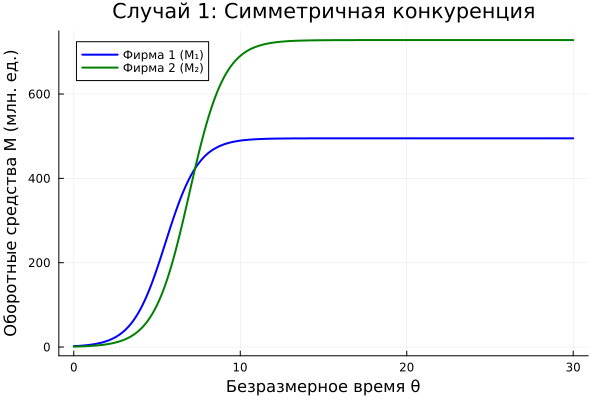

In [24]:
plot_case1 = plot(θ_vals, M₁_vals,
                  label="Фирма 1 (M₁)", color=:blue, linewidth=2,
                  xlabel="Безразмерное время θ", ylabel="Оборотные средства M (млн. ед.)",
                  title="Случай 1: Симметричная конкуренция")
plot!(plot_case1, θ_vals, M₂_vals,
      label="Фирма 2 (M₂)", color=:green, linewidth=2)

display(plot_case1)

----------------------------------------------------------------------------
Случай 2: Асимметричная конкуренция (дополнительное влияние на фирму 1)
Уравнения: dM₁/dθ = M₁ - (B + δ)·M₁·M₂ - A₁·M₁²
           dM₂/dθ = C₂·M₂ - B·M₁·M₂ - A₂·M₂²
----------------------------------------------------------------------------

In [26]:
println("\n" * "="^70)
println("СЛУЧАЙ 2: Асимметричная конкуренция (социально-психологические факторы)")
println("="^70)

δ = 0.002   # дополнительный коэффициент влияния на фирму 1
B₂ = B + δ

function competition_case2!(du, u, p, θ)
    A₁, A₂, B, B₂, C₂ = p
    M₁, M₂ = u
    du[1] = M₁ - A₁ * M₁^2 - B₂ * M₁ * M₂
    du[2] = C₂ * M₂ - A₂ * M₂^2 - B * M₁ * M₂
end

u0_case2 = [M₁₀, M₂₀]
params_case2 = (A₁, A₂, B, B₂, C₂)

prob_case2 = ODEProblem(competition_case2!, u0_case2, θ_span, params_case2)
sol_case2 = solve(prob_case2, saveat=0.05)

M₁_vals2 = [u[1] for u in sol_case2.u]
M₂_vals2 = [u[2] for u in sol_case2.u]


СЛУЧАЙ 2: Асимметричная конкуренция (социально-психологические факторы)


601-element Vector{Float64}:
   1.0
   1.0485591188411745
   1.0994726579530743
   1.1528544746671077
   1.2088237090625613
   1.2675053466624067
   1.3290305194802245
   1.393536506042095
   1.4611671803071489
   1.5320730582782378
   1.6064117820846073
   1.6843490572589208
   1.7660586563073977
   ⋮
 727.9999977809323
 727.9999978426555
 727.9999979024271
 727.9999979603185
 727.999998016399
 727.999998070736
 727.9999981233949
 727.9999981744393
 727.9999982239308
 727.9999982719291
 727.999998318492
 727.9999983636752

График для случая 2

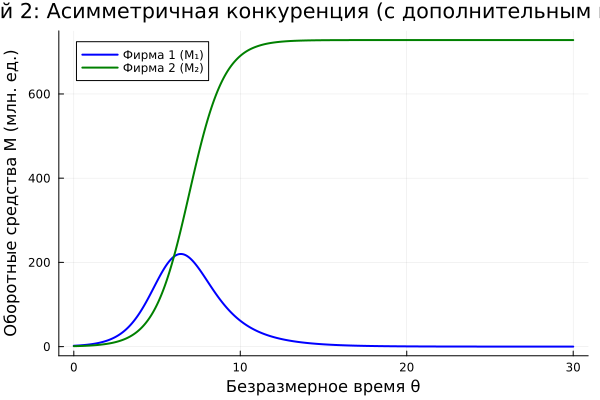

In [28]:
plot_case2 = plot(θ_vals, M₁_vals2,
                  label="Фирма 1 (M₁)", color=:blue, linewidth=2,
                  xlabel="Безразмерное время θ", ylabel="Оборотные средства M (млн. ед.)",
                  title="Случай 2: Асимметричная конкуренция (с дополнительным влиянием)")
plot!(plot_case2, θ_vals, M₂_vals2,
      label="Фирма 2 (M₂)", color=:green, linewidth=2)

display(plot_case2)

----------------------------------------------------------------------------
Сравнение двух случаев на одном графике
----------------------------------------------------------------------------

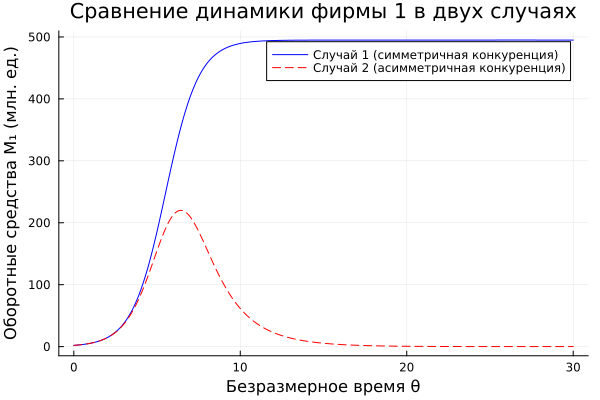

In [30]:
plot_comparison = plot(title="Сравнение динамики фирмы 1 в двух случаях",
                       xlabel="Безразмерное время θ", ylabel="Оборотные средства M₁ (млн. ед.)",
                       legend=:topright, linewidth=2)
plot!(plot_comparison, θ_vals, M₁_vals,
      label="Случай 1 (симметричная конкуренция)", color=:blue)
plot!(plot_comparison, θ_vals, M₁_vals2,
      label="Случай 2 (асимметричная конкуренция)", color=:red, linestyle=:dash)

display(plot_comparison)

----------------------------------------------------------------------------
Задание 2: Анализ полученных результатов
----------------------------------------------------------------------------

In [32]:
println("\n" * "="^70)
println("ЗАДАНИЕ 2: Анализ результатов")
println("="^70)


ЗАДАНИЕ 2: Анализ результатов


Расчет стационарных значений для случая 1
Стационарное состояние находится из системы: M₁ - A₁·M₁² - B·M₁·M₂ = 0, C₂·M₂ - A₂·M₂² - B·M₁·M₂ = 0
При M₁ > 0, M₂ > 0:

Из первого уравнения: 1 - A₁·M₁ - B·M₂ = 0 → M₂ = (1 - A₁·M₁)/B
Из второго уравнения: C₂ - A₂·M₂ - B·M₁ = 0

Подставляя: C₂ - A₂·(1 - A₁·M₁)/B - B·M₁ = 0
Умножаем на B: C₂·B - A₂·(1 - A₁·M₁) - B²·M₁ = 0
C₂·B - A₂ + A₂·A₁·M₁ - B²·M₁ = 0
M₁·(A₁·A₂ - B²) = A₂ - C₂·B
M₁* = (A₂ - C₂·B) / (A₁·A₂ - B²)

M₂* = (1 - A₁·M₁*)/B

In [37]:
M₁_stationary = (A₂ - C₂ * B) / (A₁ * A₂ - B^2)
M₂_stationary = (1 - A₁ * M₁_stationary) / B

println("\nСтационарное состояние системы (Случай 1):")
println("M₁* = $(round(M₁_stationary, digits=4)) млн. ед.")
println("M₂* = $(round(M₂_stationary, digits=4)) млн. ед.")


Стационарное состояние системы (Случай 1):
M₁* = 494.942 млн. ед.
M₂* = 727.9389 млн. ед.


Проверка стационарности

In [39]:
check1 = M₁_stationary - A₁ * M₁_stationary^2 - B * M₁_stationary * M₂_stationary
check2 = C₂ * M₂_stationary - A₂ * M₂_stationary^2 - B * M₁_stationary * M₂_stationary
println("Проверка: dM₁/dθ = $(round(check1, digits=10)), dM₂/dθ = $(round(check2, digits=10))")

Проверка: dM₁/dθ = -0.0, dM₂/dθ = -2.0e-10


----------------------------------------------------------------------------
Задание 3: Стационарные значения для случая 1
----------------------------------------------------------------------------

In [41]:
println("\n" * "="^70)
println("ЗАДАНИЕ 3: Стационарное состояние системы (Случай 1)")
println("="^70)

println("\nСтационарные значения (формулы 9 из теории):")
M₁_plus = N * q * (τ₁ / 1) * (1 - p̃₁ / p_cr) * p̃₁
M₂_plus = N * q * (τ₂ / 1) * (1 - p̃₂ / p_cr) * p̃₂

println("M₁_стац = N·q·τ₁·(1 - p̃₁/p_cr)·p̃₁ = $(round(M₁_plus, digits=2)) млн. ед.")
println("M₂_стац = N·q·τ₂·(1 - p̃₂/p_cr)·p̃₂ = $(round(M₂_plus, digits=2)) млн. ед.")

println("\nСтационарные значения, полученные из решения системы:")
println("M₁* = $(round(M₁_stationary, digits=4)) млн. ед.")
println("M₂* = $(round(M₂_stationary, digits=4)) млн. ед.")


ЗАДАНИЕ 3: Стационарное состояние системы (Случай 1)

Стационарные значения (формулы 9 из теории):
M₁_стац = N·q·τ₁·(1 - p̃₁/p_cr)·p̃₁ = 495.0 млн. ед.
M₂_стац = N·q·τ₂·(1 - p̃₂/p_cr)·p̃₂ = 728.0 млн. ед.

Стационарные значения, полученные из решения системы:
M₁* = 494.942 млн. ед.
M₂* = 727.9389 млн. ед.


----------------------------------------------------------------------------
Дополнительный анализ: влияние параметров на стационарные значения
----------------------------------------------------------------------------


ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: Влияние себестоимости на стационарные значения


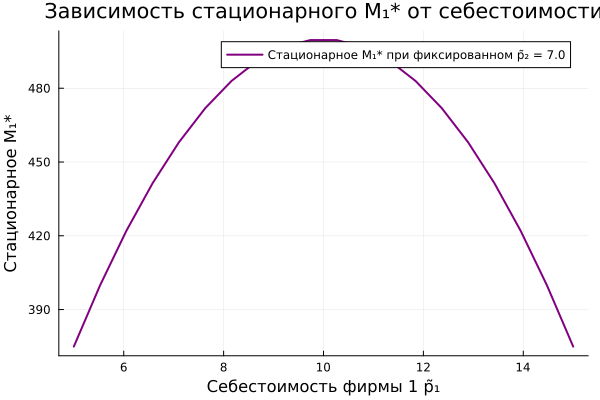

In [43]:
println("\n" * "="^70)
println("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: Влияние себестоимости на стационарные значения")
println("="^70)

p̃₁_range = range(5.0, 15.0, length=20)
p̃₂_range = range(5.0, 15.0, length=20)

function compute_stationary_M1(p̃₁_val, p̃₂_val)
    a₁_val = p_cr / (τ₁^2 * p̃₁_val^2 * N * q)
    a₂_val = p_cr / (τ₂^2 * p̃₂_val^2 * N * q)
    b_val = p_cr / (τ₁^2 * τ₂^2 * p̃₁_val^2 * p̃₂_val^2 * N * q)
    c₁_val = (p_cr - p̃₁_val) / (τ₁ * p̃₁_val)
    c₂_val = (p_cr - p̃₂_val) / (τ₂ * p̃₂_val)

    A₁_val = a₁_val / c₁_val
    A₂_val = a₂_val / c₁_val
    B_val = b_val / c₁_val
    C₂_val = c₂_val / c₁_val

    M₁_st = (A₂_val - C₂_val * B_val) / (A₁_val * A₂_val - B_val^2)
    return M₁_st
end

M₁_stationary_vs_p̃₁ = [compute_stationary_M1(p̃₁_val, p̃₂) for p̃₁_val in p̃₁_range]

plot_sensitivity = plot(p̃₁_range, M₁_stationary_vs_p̃₁,
                        label="Стационарное M₁* при фиксированном p̃₂ = $p̃₂",
                        xlabel="Себестоимость фирмы 1 p̃₁", ylabel="Стационарное M₁*",
                        title="Зависимость стационарного M₁* от себестоимости",
                        linewidth=2, color=:purple)

display(plot_sensitivity)

----------------------------------------------------------------------------
Выводы
----------------------------------------------------------------------------

In [45]:
println("\n" * "="^70)
println("ВЫВОДЫ")
println("="^70)

println("\n1. Случай 1 (симметричная конкуренция):")
println("   • Обе фирмы достигают устойчивых стационарных значений")
println("   • Фирма 1 с более коротким циклом (τ₁=10) достигает большего стационарного значения")
println("   • Фирма 2 с более длинным циклом (τ₂=16) имеет меньший стационарный объем")
println("   • Фирмы сосуществуют, каждая занимает свою нишу на рынке")

println("\n2. Случай 2 (асимметричная конкуренция с социально-психологическими факторами):")
println("   • Фирма 1, несмотря на начальный рост, начинает нести убытки")
println("   • Влияние дополнительного коэффициента δ = $δ приводит к банкротству фирмы 1")
println("   • Фирма 2 сохраняет свою стационарную динамику")
println("   • Это демонстрирует важность нематериальных факторов конкуренции")

println("\n3. Экономическая интерпретация:")
println("   • Более эффективное производство (меньшая себестоимость) дает конкурентное преимущество")
println("   • Длительность производственного цикла критически влияет на устойчивость")
println("   • Социально-психологические факторы могут изменить исход конкурентной борьбы")
println("   • Для выживания на рынке необходимо учитывать не только экономические, но и маркетинговые факторы")

println("\n4. Стационарное состояние:")
println("   • В случае 1 существует устойчивое стационарное состояние")
println("   • M₁* = $(round(M₁_stationary, digits=4)) млн. ед., M₂* = $(round(M₂_stationary, digits=4)) млн. ед.")
println("   • Это состояние соответствует равновесному распределению рынка между фирмами")


ВЫВОДЫ

1. Случай 1 (симметричная конкуренция):
   • Обе фирмы достигают устойчивых стационарных значений
   • Фирма 1 с более коротким циклом (τ₁=10) достигает большего стационарного значения
   • Фирма 2 с более длинным циклом (τ₂=16) имеет меньший стационарный объем
   • Фирмы сосуществуют, каждая занимает свою нишу на рынке

2. Случай 2 (асимметричная конкуренция с социально-психологическими факторами):
   • Фирма 1, несмотря на начальный рост, начинает нести убытки
   • Влияние дополнительного коэффициента δ = 0.002 приводит к банкротству фирмы 1
   • Фирма 2 сохраняет свою стационарную динамику
   • Это демонстрирует важность нематериальных факторов конкуренции

3. Экономическая интерпретация:
   • Более эффективное производство (меньшая себестоимость) дает конкурентное преимущество
   • Длительность производственного цикла критически влияет на устойчивость
   • Социально-психологические факторы могут изменить исход конкурентной борьбы
   • Для выживания на рынке необходимо учит